# V8 · Stage 1.2e — Frozen selector applied to all Longterm cells

**Question**: with the frozen hybrid rule (context-holdout residual with
threshold τ = 0.540 pp), how many cells across the Longterm cohort
would route to the neural operator vs to exponential extrapolation?

**Method**:

1. Enumerate every `<make>_Longterm_cell_<cell_id>.csv` in `Data/Longterm/`.
2. For each cell with at least $K=50$ observed cycles, compute the
   context-holdout residual $r$: fit exp on the first 80% of the
   $K{=}50$ context, RMSE on the last 20%.
3. Apply the frozen threshold $\tau = 0.540$ pp — cell routed to
   **exponential** if $r < \tau$, else to **neural operator**.
4. Aggregate per supplier and visualise.

**Notes**:

- Threshold $\tau = 0.540$ pp was fixed by `01_2d` on the synthetic
  `validation_selector` pool — never touched during this notebook.
- The distinction here is the *decision* the selector makes, not the
  forecast RMSE (which would need per-cell θ + DCIR + operator
  inference; many non-anchor cells lack the necessary metadata).

**Expected outputs**:

- `outputs/results/selector_on_all_cells.parquet`
- `outputs/results/selector_on_all_cells.pdf`


## 1. Setup

In [1]:
import sys, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJ = Path("/home/hj/Desktop/PINNs")
sys.path.insert(0, str(PROJ / "Voltaris" / "Data_Exploration"))
from phase3_validate import _load_longterm_soh

LONGTERM_DIR = PROJ / "Data" / "Longterm"
K = 50
CTX_TAIL = 10   # last 20% of K=50 context
TAU = 0.540


## 2. Residual + pick per cell

In [2]:
def _exp(n, a, b, c): return a * np.exp(-b * n) + c

def context_holdout_residual(context_soh, K=K, tail=CTX_TAIL):
    n_fit = np.arange(K - tail, dtype=float)
    y_fit = np.asarray(context_soh[:K - tail], dtype=float)
    n_val = np.arange(K - tail, K, dtype=float)
    y_val = np.asarray(context_soh[K - tail:K], dtype=float)
    try:
        popt, _ = curve_fit(_exp, n_fit, y_fit,
                            p0=[y_fit[0]-y_fit[-1], 1e-3, y_fit[-1]],
                            maxfev=10000)
        y_hat = _exp(n_val, *popt)
        return float(np.sqrt(np.mean((y_hat - y_val)**2)) * 100)
    except Exception:
        return float("nan")

_pat = re.compile(r"^(?P<make>[A-Za-z]+)_Longterm_cell_(?P<cell_id>\d+)(?:_[A-Za-z]+)?\.csv$")

rows = []
csvs = sorted(LONGTERM_DIR.glob("*.csv"))
print(f"scanning {len(csvs)} Longterm CSVs...")
_seen = set()
for p in csvs:
    m = _pat.match(p.name)
    if not m: continue
    mk = m.group("make"); cid = m.group("cell_id")
    key = (mk, cid)
    if key in _seen: continue    # dedupe cells with both foo.csv and foo_cycle.csv
    _seen.add(key)
    try:
        obs_n, obs_soh = _load_longterm_soh(cid, mk)
    except Exception as e:
        rows.append({"cell": f"{mk}_{cid}", "make": mk, "cell_id": cid,
                     "n_cycles": 0, "reason": str(e)[:80]})
        continue
    if len(obs_soh) < K:
        rows.append({"cell": f"{mk}_{cid}", "make": mk, "cell_id": cid,
                     "n_cycles": int(len(obs_soh)),
                     "reason": f"<K={K} cycles"})
        continue
    ctx = obs_soh[:K]
    residual = context_holdout_residual(ctx)
    if not np.isfinite(residual):
        rows.append({"cell": f"{mk}_{cid}", "make": mk, "cell_id": cid,
                     "n_cycles": int(len(obs_soh)),
                     "reason": "residual fit failed"})
        continue
    pick = "exp" if residual < TAU else "operator"
    rows.append({
        "cell": f"{mk}_{cid}",
        "make": mk,
        "cell_id": cid,
        "n_cycles": int(len(obs_soh)),
        "soh_start": float(ctx[0]),
        "soh_end_context": float(ctx[-1]),
        "context_holdout_residual_pp": residual,
        "pick": pick,
    })
df = pd.DataFrame(rows)
print(f"\ncells scanned: {len(df)}")
scored = df[df["context_holdout_residual_pp"].notna()]
print(f"cells with residual: {len(scored)}")
print(f"cells skipped: {len(df) - len(scored)}")


scanning 75 Longterm CSVs...



cells scanned: 61
cells with residual: 59
cells skipped: 2


## 3. Pick distribution per supplier

In [3]:
summary = (scored.groupby(["make", "pick"]).size()
                    .unstack(fill_value=0)
                    .reindex(columns=["exp", "operator"], fill_value=0))
summary["total"] = summary["exp"] + summary["operator"]
summary["pct_operator"] = (summary["operator"] / summary["total"] * 100).round(1)
summary


pick,exp,operator,total,pct_operator
make,,,,
CALB,26,1,27,3.7
EVE,4,2,6,33.3
REPT,22,4,26,15.4


## 4. Overall totals

In [4]:
overall = scored["pick"].value_counts().reindex(["exp", "operator"], fill_value=0)
print(f"Frozen τ = {TAU:.3f} pp")
print(f"Total scored cells: {len(scored)}")
print(f"  → exponential: {int(overall['exp'])} "
      f"({overall['exp']/len(scored)*100:.1f}%)")
print(f"  → neural operator: {int(overall['operator'])} "
      f"({overall['operator']/len(scored)*100:.1f}%)")


Frozen τ = 0.540 pp
Total scored cells: 59
  → exponential: 52 (88.1%)
  → neural operator: 7 (11.9%)


## 5. Visualise

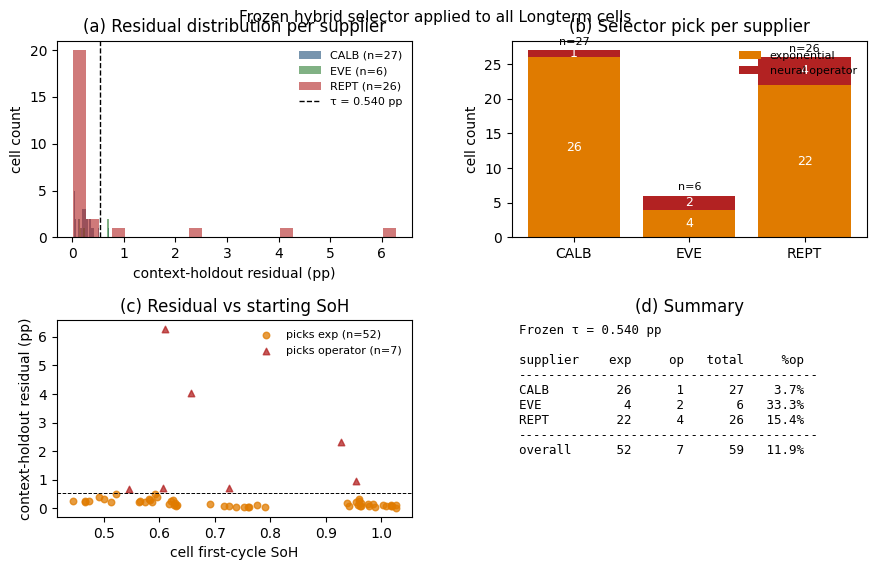

wrote /home/hj/Desktop/PINNs/outputs/results/selector_on_all_cells.pdf
wrote /home/hj/Desktop/PINNs/outputs/results/selector_on_all_cells.png


In [5]:
SUPPLIER_COLOR = {"CALB": "#1F4E79", "EVE": "#2E7D32", "REPT": "#B22222"}
EXP_C, OP_C = "#E07B00", "#B22222"

fig = plt.figure(figsize=(9, 5.6),
    constrained_layout=False)
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.28,
                       left=0.08, right=0.98, top=0.94, bottom=0.09)

# (A) Residual histogram per supplier, with τ marker
ax1 = fig.add_subplot(gs[0, 0])
for mk in ["CALB", "EVE", "REPT"]:
    vals = scored.loc[scored["make"] == mk,
                       "context_holdout_residual_pp"].values
    if len(vals):
        ax1.hist(vals, bins=25, alpha=0.60, label=f"{mk} (n={len(vals)})",
                  color=SUPPLIER_COLOR[mk], edgecolor="none")
ax1.axvline(TAU, color="black", lw=1.0, ls="--",
             label=f"τ = {TAU:.3f} pp")
ax1.set_xlabel("context-holdout residual (pp)")
ax1.set_ylabel("cell count")
ax1.set_title("(a) Residual distribution per supplier")
ax1.legend(fontsize=8, frameon=False)

# (B) Stacked bar: pick per supplier
ax2 = fig.add_subplot(gs[0, 1])
bars_exp = summary["exp"].values
bars_op  = summary["operator"].values
suppliers = summary.index.tolist()
x = np.arange(len(suppliers))
ax2.bar(x, bars_exp, color=EXP_C, label="exponential")
ax2.bar(x, bars_op, bottom=bars_exp, color=OP_C, label="neural operator")
for i, (e, o, t) in enumerate(zip(bars_exp, bars_op, summary["total"])):
    if e: ax2.text(i, e/2, str(int(e)), ha="center", va="center",
                    color="white", fontsize=9)
    if o: ax2.text(i, e + o/2, str(int(o)), ha="center", va="center",
                    color="white", fontsize=9)
    ax2.text(i, t + 0.5, f"n={t}", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(suppliers)
ax2.set_ylabel("cell count")
ax2.set_title("(b) Selector pick per supplier")
ax2.legend(fontsize=8, frameon=False, loc="upper right")

# (C) Scatter: initial SoH vs residual, coloured by pick
ax3 = fig.add_subplot(gs[1, 0])
for pick, color, marker in [("exp", EXP_C, "o"),
                             ("operator", OP_C, "^")]:
    sub = scored[scored["pick"] == pick]
    ax3.scatter(sub["soh_start"], sub["context_holdout_residual_pp"],
                 color=color, marker=marker, s=22, alpha=0.75,
                 label=f"picks {pick} (n={len(sub)})")
ax3.axhline(TAU, color="black", lw=0.7, ls="--")
ax3.set_xlabel("cell first-cycle SoH")
ax3.set_ylabel("context-holdout residual (pp)")
ax3.set_title("(c) Residual vs starting SoH")
ax3.legend(fontsize=8, frameon=False, loc="upper right")

# (D) Table summary (as image)
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
tbl_text = ["Frozen τ = 0.540 pp", ""]
tbl_text.append(f"{'supplier':<8} {'exp':>6} {'op':>6} {'total':>7} {'%op':>7}")
tbl_text.append("-" * 40)
for mk, row in summary.iterrows():
    tbl_text.append(f"{mk:<8} {int(row['exp']):>6d} {int(row['operator']):>6d} "
                     f"{int(row['total']):>7d} {row['pct_operator']:>6.1f}%")
tbl_text.append("-" * 40)
tbl_text.append(f"{'overall':<8} {int(overall['exp']):>6d} "
                 f"{int(overall['operator']):>6d} "
                 f"{len(scored):>7d} "
                 f"{overall['operator']/len(scored)*100:>6.1f}%")
ax4.text(0.02, 0.98, "\n".join(tbl_text), transform=ax4.transAxes,
         family="monospace", fontsize=9, va="top", ha="left")
ax4.set_title("(d) Summary")

fig.suptitle("Frozen hybrid selector applied to all Longterm cells",
             fontsize=11, y=0.995)
out_pdf = PROJ / "outputs/results/selector_on_all_cells.pdf"
out_png = PROJ / "outputs/results/selector_on_all_cells.png"
fig.savefig(out_pdf, dpi=200, bbox_inches="tight")
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out_pdf}\nwrote {out_png}")


## 6. Persist per-cell decisions

In [6]:
out_parquet = PROJ / "outputs/results/selector_on_all_cells.parquet"
df.to_parquet(out_parquet, index=False)
print(f"wrote {out_parquet}")

# Also print the top-10 residual (most "complex") cells for inspection
print("\ntop 10 most complex (highest residual) cells:")
print(scored.nlargest(10, "context_holdout_residual_pp")
        [["cell","make","n_cycles","soh_start","context_holdout_residual_pp","pick"]]
        .to_string(index=False, float_format="%.4f"))

print("\ntop 10 least complex (lowest residual) cells:")
print(scored.nsmallest(10, "context_holdout_residual_pp")
        [["cell","make","n_cycles","soh_start","context_holdout_residual_pp","pick"]]
        .to_string(index=False, float_format="%.4f"))


wrote /home/hj/Desktop/PINNs/outputs/results/selector_on_all_cells.parquet

top 10 most complex (highest residual) cells:
     cell make  n_cycles  soh_start  context_holdout_residual_pp     pick
REPT_0034 REPT       201     0.6094                       6.2756 operator
REPT_0011 REPT       201     0.6569                       4.0347 operator
REPT_0037 REPT       201     0.9269                       2.3337 operator
REPT_0032 REPT       201     0.9545                       0.9648 operator
CALB_0020 CALB       201     0.6060                       0.7225 operator
 EVE_0003  EVE       150     0.7259                       0.7071 operator
 EVE_0001  EVE       150     0.5463                       0.6856 operator
CALB_0012 CALB       201     0.5219                       0.5118      exp
REPT_0080 REPT       150     0.5920                       0.5060      exp
CALB_0013 CALB       201     0.4913                       0.3981      exp

top 10 least complex (lowest residual) cells:
     cell make  n

## 7. Per-cell observed vs forecast (small multiples)

For a representative subset of cells (highest-, median- and
lowest-residual per supplier), overlay the observed SoH, the
exponential forecast, and the neural-operator forecast on the same
panel — the abstract's Figure 2 layout, extended to more cells. Grey
band = $K{=}50$ context. Panels use independent y-axis ranges.


In [7]:
import torch
from phase3_v7_validate import OperatorV7, forecast_v7

V8_CKPT = PROJ / "outputs/models/pinn_phase3_v8_clean.pt"
ckpt = torch.load(V8_CKPT, map_location="cpu", weights_only=False)
model = OperatorV7(K=K)
model.load_state_dict(ckpt["state_dict"])
model.set_x_health_stats(torch.tensor(ckpt["xh_mean"]), torch.tensor(ckpt["xh_std"]))
model.set_theta_stats(torch.tensor(ckpt["th_mean"]), torch.tensor(ckpt["th_std"]))
model.eval()

def _try_operator_over_observed(cid, mk, obs_n, obs_soh):
    try:
        r = forecast_v7(model, cid, mk, K=K,
                         forecast_len=int(len(obs_n) - K))
        pred_n = np.asarray(r["pred_cycles"], dtype=float)
        pred_soh = np.asarray(r["pred_soh"], dtype=float)
        rmse = float(r["rmse_pp_covered"])
        return pred_n, pred_soh, rmse
    except Exception:
        return None, None, None

def _exp_over_observed(obs_n, obs_soh):
    ctx = obs_soh[:K]
    popt, _ = curve_fit(_exp, np.arange(K, dtype=float), ctx,
                        p0=[ctx[0]-ctx[-1], 1e-3, ctx[-1]], maxfev=10000)
    tgt_n = obs_n[K:]
    exp_pred = _exp(tgt_n.astype(float) - float(obs_n[0]), *popt)
    rmse = float(np.sqrt(np.mean((exp_pred - obs_soh[K:])**2)) * 100)
    return tgt_n, exp_pred, rmse

# Select 3 cells per supplier: highest-, median-, lowest-residual
def _pick3(sub):
    sub = sub.sort_values("context_holdout_residual_pp").reset_index(drop=True)
    if len(sub) == 0: return sub
    idxs = sorted({0, len(sub)//2, len(sub)-1})
    return sub.iloc[idxs]

pick_rows = []
for mk in ["CALB", "EVE", "REPT"]:
    picks = _pick3(scored[scored["make"] == mk])
    for _, r in picks.iterrows():
        pick_rows.append(r)
selected = pd.DataFrame(pick_rows).reset_index(drop=True)
print("selected cells for the per-cell grid:")
print(selected[["cell","make","context_holdout_residual_pp","pick"]].to_string(index=False))


selected cells for the per-cell grid:
     cell make  context_holdout_residual_pp     pick
CALB_0015 CALB                     0.028634      exp
CALB_0027 CALB                     0.226911      exp
CALB_0020 CALB                     0.722526 operator
 EVE_0004  EVE                     0.126264      exp
 EVE_0008  EVE                     0.226745      exp
 EVE_0003  EVE                     0.707057 operator
REPT_0087 REPT                     0.018689      exp
REPT_0043 REPT                     0.116379      exp
REPT_0034 REPT                     6.275632 operator


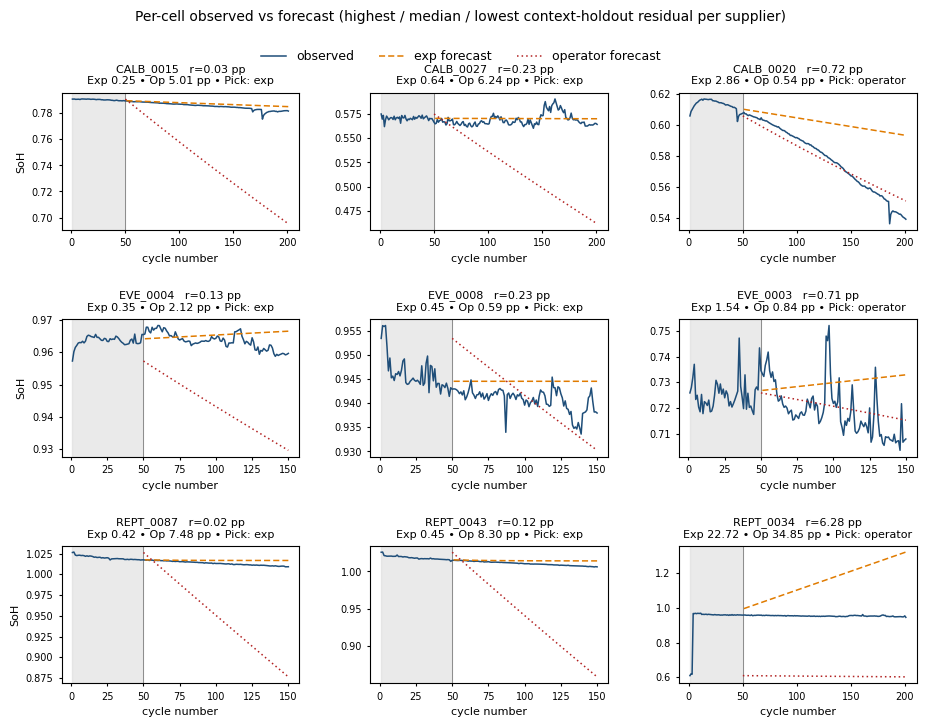

wrote /home/hj/Desktop/PINNs/outputs/results/selector_per_cell_grid.pdf


In [8]:
OBS_COLOR = "#1F4E79"
EXP_COLOR = "#E07B00"
OP_COLOR = "#B22222"
CTX_GREY = "0.85"
BOUNDARY = "0.55"

rows = 3   # one row per supplier
cols = 3   # highest / median / lowest residual
fig, axes = plt.subplots(rows, cols, figsize=(9.5, 7.2),
    gridspec_kw=dict(wspace=0.30, hspace=0.65, left=0.08, right=0.98,
                      bottom=0.06, top=0.88))
handles = []
for i, mk in enumerate(["CALB", "EVE", "REPT"]):
    sub_selected = selected[selected["make"] == mk].reset_index(drop=True)
    for j in range(cols):
        ax = axes[i, j]
        if j >= len(sub_selected):
            ax.set_axis_off(); continue
        row = sub_selected.iloc[j]
        cid = row["cell_id"]
        try:
            obs_n, obs_soh = _load_longterm_soh(cid, mk)
        except Exception:
            ax.set_axis_off(); continue
        obs_n = np.asarray(obs_n, dtype=float)
        obs_soh = np.asarray(obs_soh, dtype=float)
        n_ctx = obs_n[:K]; y_ctx = obs_soh[:K]

        # Grey context band + boundary at cycle K
        ax.axvspan(int(n_ctx[0]), int(n_ctx[-1]), color=CTX_GREY,
                   alpha=0.55, zorder=0)
        ax.axvline(int(n_ctx[-1]), color=BOUNDARY, lw=0.7, ls="-", zorder=1)

        h_obs, = ax.plot(obs_n, obs_soh, color=OBS_COLOR, lw=1.1,
                          zorder=3, label="observed")
        # Exp forecast
        try:
            tgt_n, exp_pred, rmse_exp = _exp_over_observed(obs_n, obs_soh)
            h_exp, = ax.plot(tgt_n, exp_pred, color=EXP_COLOR, lw=1.1,
                              ls=(0, (4, 2)), zorder=4, label="exp forecast")
        except Exception:
            exp_pred = None; rmse_exp = float("nan")
        # Operator forecast (over observed horizon)
        pred_n, pred_soh, rmse_op = _try_operator_over_observed(
            cid, mk, obs_n, obs_soh)
        if pred_n is not None:
            mask = pred_n <= float(obs_n[-1])
            h_op, = ax.plot(pred_n[mask], pred_soh[mask], color=OP_COLOR,
                             lw=1.1, ls=(0, (1, 2)), zorder=4,
                             label="operator forecast")
        else:
            rmse_op = float("nan")

        # Two-line title with residual + RMSEs + selector pick
        rmse_exp_str = f"{rmse_exp:.2f}" if np.isfinite(rmse_exp) else "n/a"
        rmse_op_str = f"{rmse_op:.2f}" if np.isfinite(rmse_op) else "n/a"
        pick_str = row["pick"]
        title = (f"{row['cell']}   r={row['context_holdout_residual_pp']:.2f} pp\n"
                 f"Exp {rmse_exp_str} • Op {rmse_op_str} pp • Pick: {pick_str}")
        ax.set_title(title, fontsize=8, linespacing=1.2)
        ax.set_xlabel("cycle number", fontsize=8)
        if j == 0:
            ax.set_ylabel("SoH", fontsize=8)
        ax.tick_params(labelsize=7, direction="out", length=2.5)

# Suptitle on top, legend just below it — no overlap with panel titles.
fig.suptitle("Per-cell observed vs forecast "
             "(highest / median / lowest context-holdout residual per supplier)",
             y=0.995, fontsize=10)
fig.legend([h_obs, h_exp, h_op],
           ["observed", "exp forecast", "operator forecast"],
           loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.955),
           frameon=False, fontsize=9)
out_pdf = PROJ / "outputs/results/selector_per_cell_grid.pdf"
fig.savefig(out_pdf, dpi=200, bbox_inches="tight")
plt.show()
print(f"wrote {out_pdf}")


## 8. Long-horizon operator projections (5000 cycles + cycles-to-EOL)

The Neural ODE has no structural horizon limit: the monotonic-softplus
decoder guarantees the predicted SoH remains monotone-decreasing at any
requested cycle. This section extends the operator forecast to
**5000 cycles** on the cells where the operator can be run at inference
(requires per-cell DCIR + a $\theta$ prior). We then extract the
**cycles-to-EOL (SoH = 0.80)** for each cell where the forecast
crosses that threshold within 5000 cycles.

**Warning**: this is a physics-informed **extrapolation** far beyond the
$K{=}50$ observed cycles per cell. It is not experimentally validated.
The 5000-cycle horizon extends about 2.5× the training-corpus horizon
of 2500 cycles and about 10× the abstract's 500-cycle claimed forecast
horizon.


In [9]:
import torch
from phase3_v7_validate import OperatorV7, forecast_v7

V8_CKPT = PROJ / "outputs/models/pinn_phase3_v8_clean.pt"
LONG_HORIZON = 5000
EOL_SOH = 0.80

ckpt = torch.load(V8_CKPT, map_location="cpu", weights_only=False)
model = OperatorV7(K=K)
model.load_state_dict(ckpt["state_dict"])
model.set_x_health_stats(torch.tensor(ckpt["xh_mean"]),
                          torch.tensor(ckpt["xh_std"]))
model.set_theta_stats(torch.tensor(ckpt["th_mean"]),
                        torch.tensor(ckpt["th_std"]))
model.eval()

def _long_forecast(cid, mk, horizon=LONG_HORIZON):
    try:
        r = forecast_v7(model, cid, mk, K=K, forecast_len=horizon)
        pred_n = np.asarray(r["pred_cycles"], dtype=float)
        pred_soh = np.asarray(r["pred_soh"], dtype=float)
        return pred_n, pred_soh, None
    except Exception as e:
        return None, None, str(e)[:100]

def _cycles_to_eol(pred_n, pred_soh, threshold=EOL_SOH):
    below = np.where(pred_soh <= threshold)[0]
    if len(below) == 0:
        return None
    return int(pred_n[below[0]])

def _is_physically_plausible(pred_soh):
    '''Operator forecast is physically plausible only if SoH stays in [0, 1.10].'''
    return bool(np.all(pred_soh >= 0.0) and np.all(pred_soh <= 1.10))

# Try every scored cell; log which ones the operator can run on
long_rows = []
for _, r in scored.iterrows():
    mk, cid = r["make"], r["cell_id"]
    pred_n, pred_soh, err = _long_forecast(cid, mk)
    if pred_n is None:
        long_rows.append({"cell": r["cell"], "make": mk, "cell_id": cid,
                           "operator_available": False, "reason": err,
                           "soh_at_500": None, "soh_at_2500": None,
                           "soh_at_5000": None, "cycles_to_EOL_0p80": None})
        continue
    # Sample SoH at key horizons + find EOL crossing
    def _at(n_target):
        idx = int(np.searchsorted(pred_n, n_target, side="left"))
        idx = min(idx, len(pred_soh) - 1)
        return float(pred_soh[idx])
    long_rows.append({"cell": r["cell"], "make": mk, "cell_id": cid,
                       "operator_available": True,
                       "reason": None,
                       "soh_at_500": _at(500),
                       "soh_at_2500": _at(2500),
                       "soh_at_5000": _at(5000),
                       "cycles_to_EOL_0p80": _cycles_to_eol(pred_n, pred_soh)})
long_df = pd.DataFrame(long_rows)
print(f"cells where operator ran: {long_df['operator_available'].sum()} "
      f"/ {len(long_df)}")
print(f"cells that cross EOL (SoH<=0.80) within 5000 cy: "
      f"{long_df['cycles_to_EOL_0p80'].notna().sum()}")


cells where operator ran: 59 / 59
cells that cross EOL (SoH<=0.80) within 5000 cy: 59


Rendering 59 individual per-cell figures...



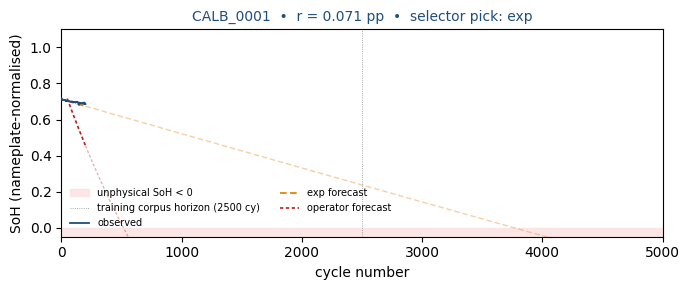

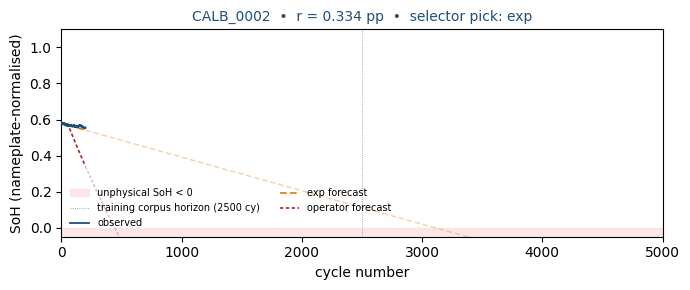

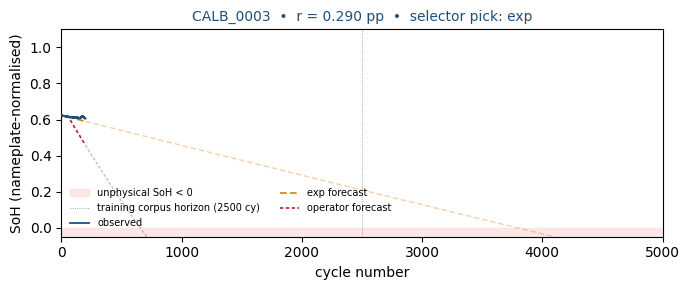

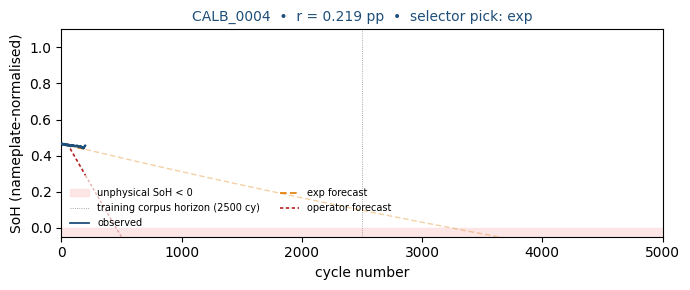

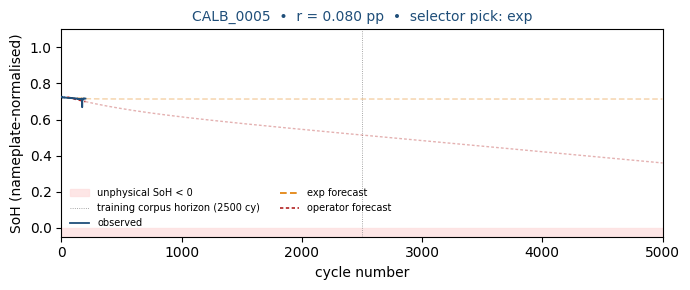

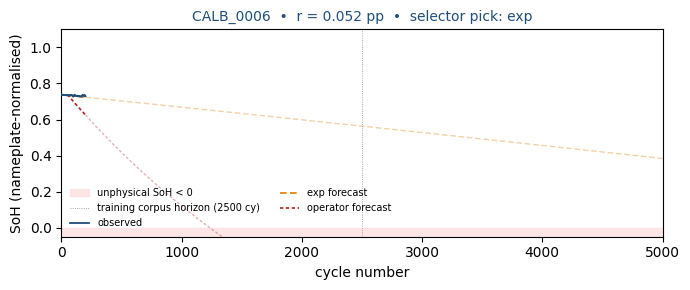

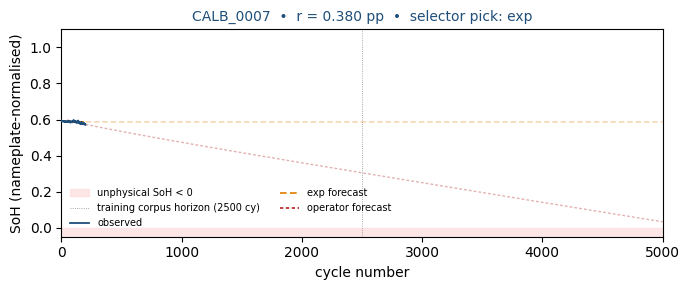

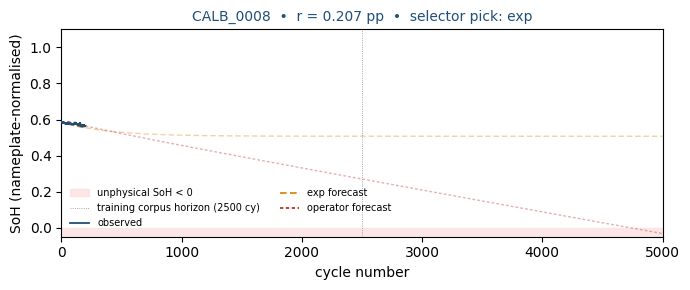

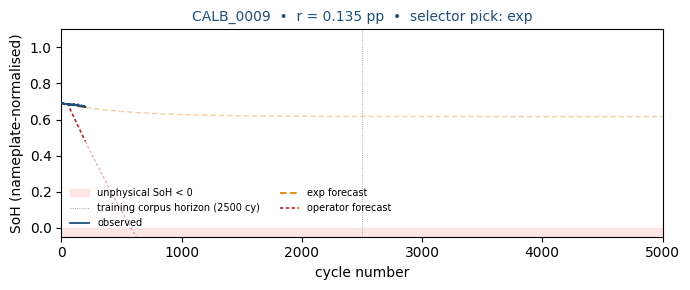

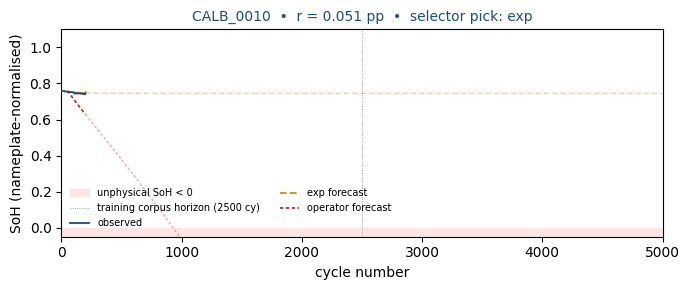

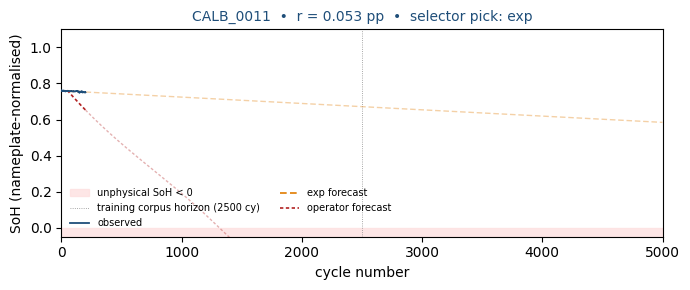

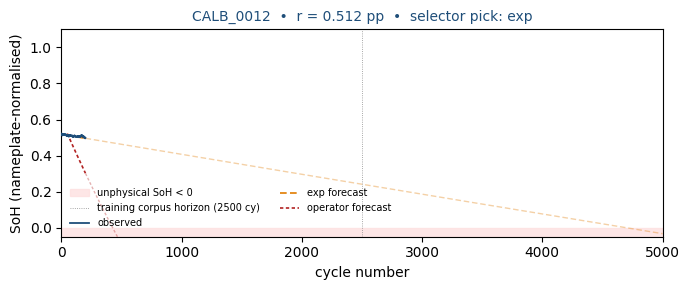

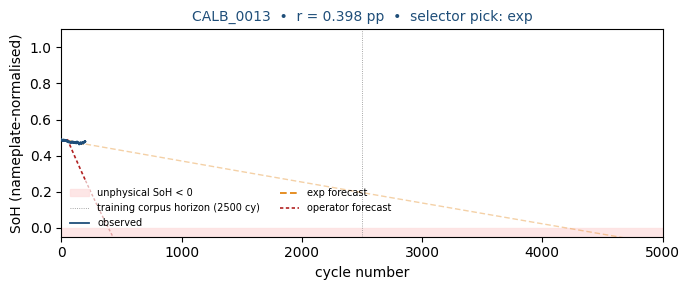

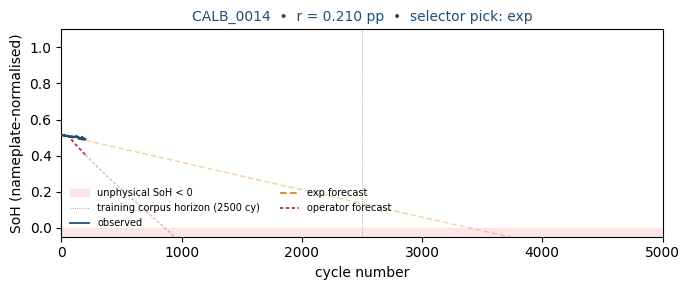

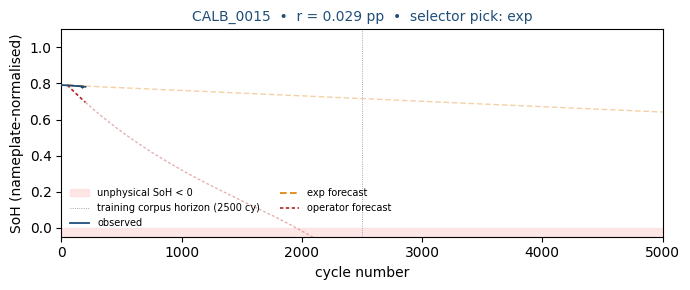

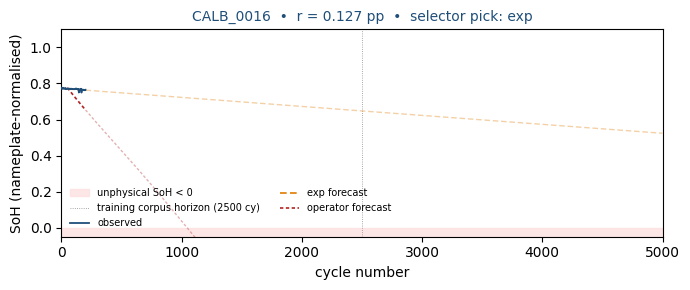

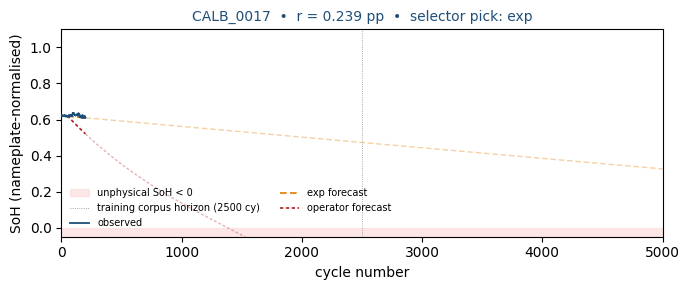

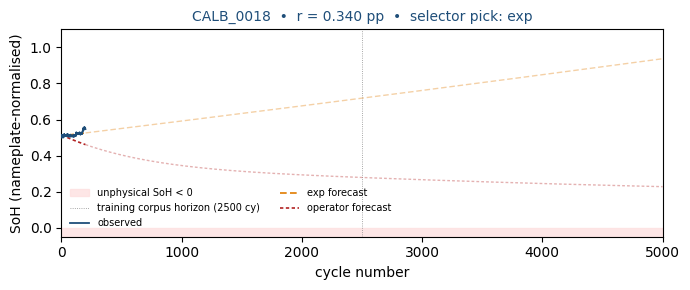

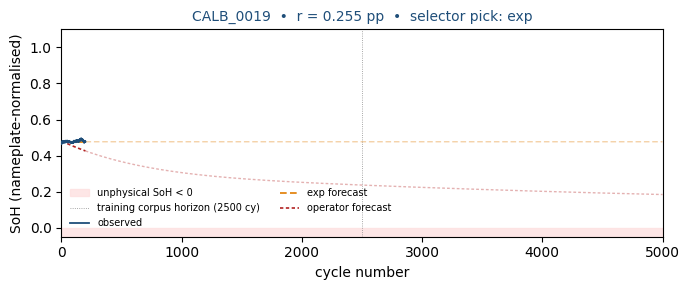

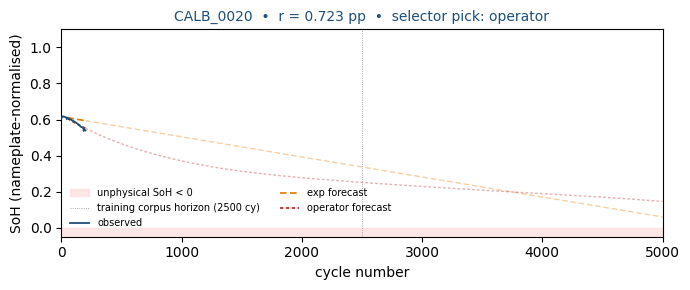

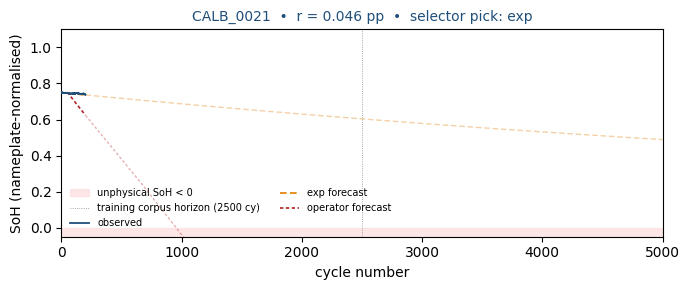

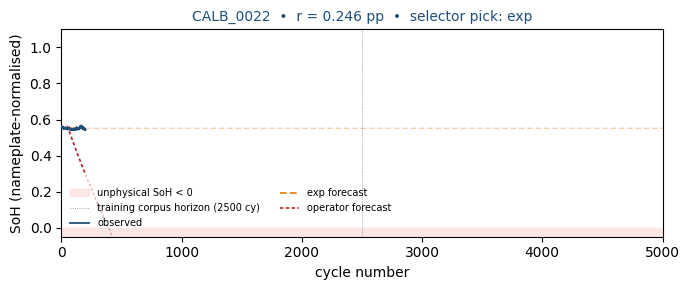

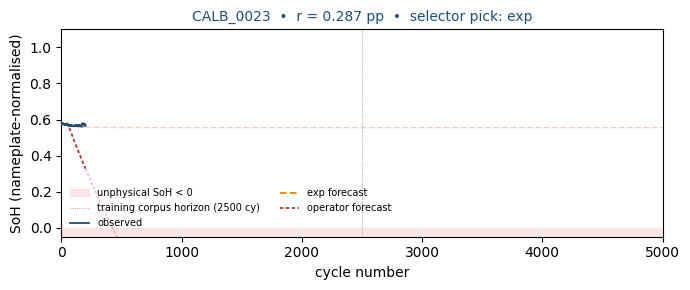

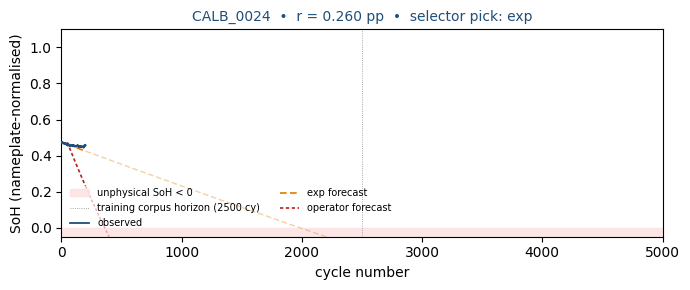

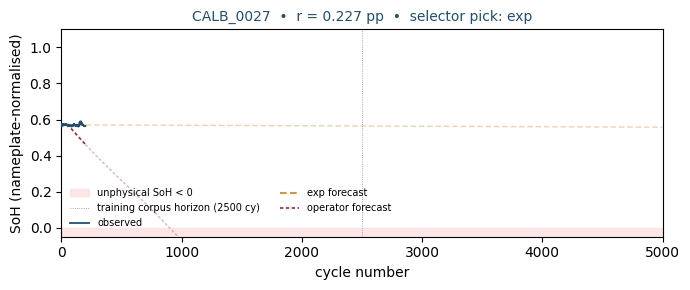

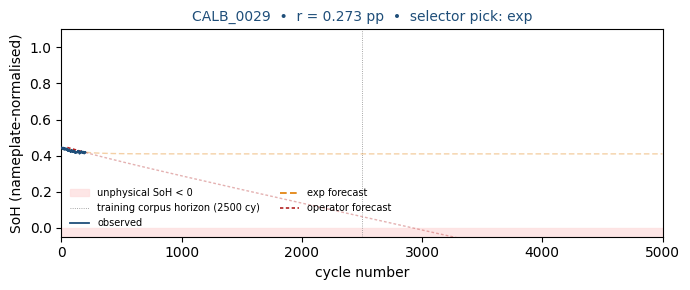

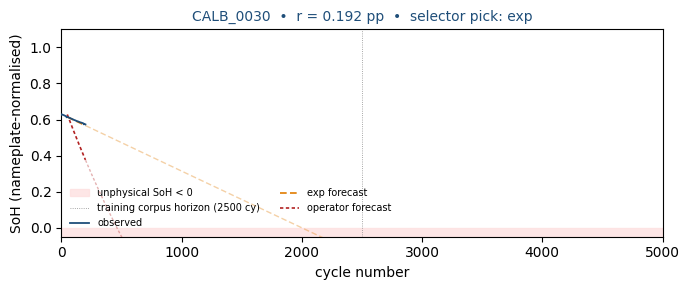

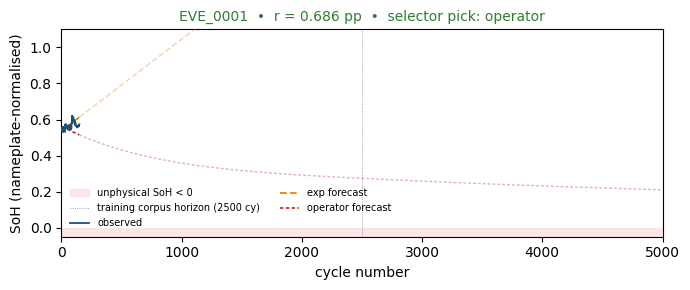

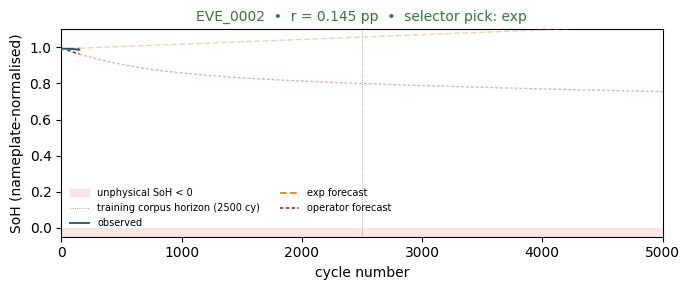

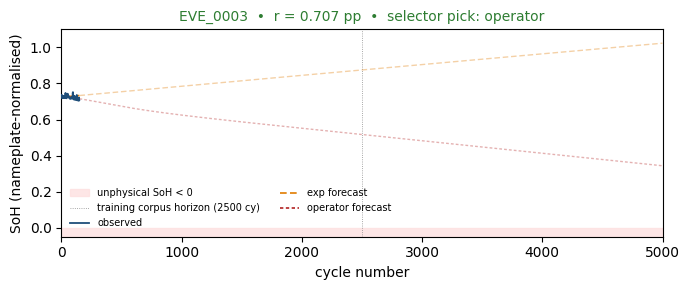

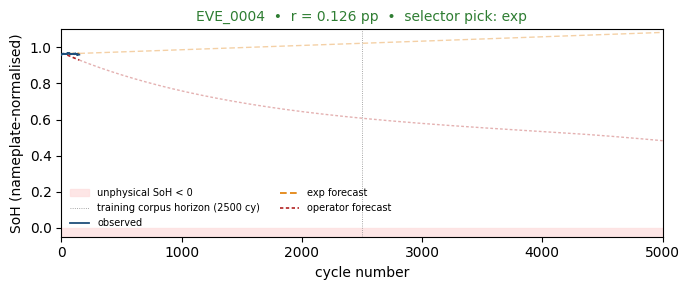

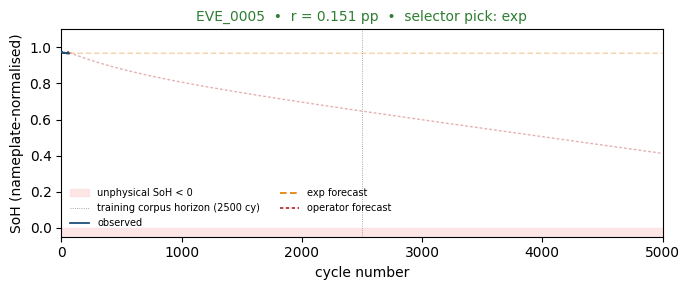

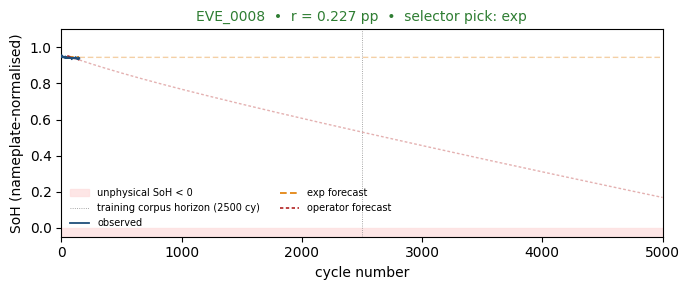

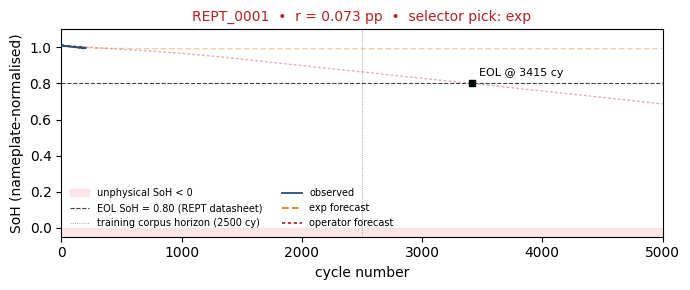

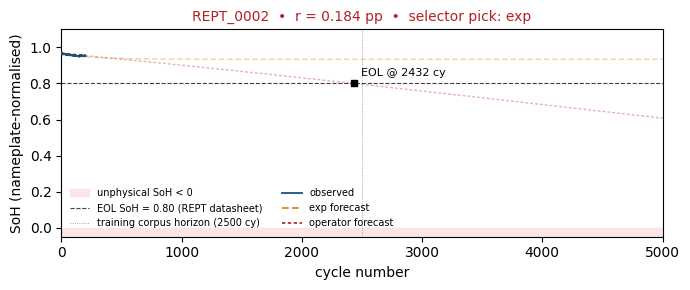

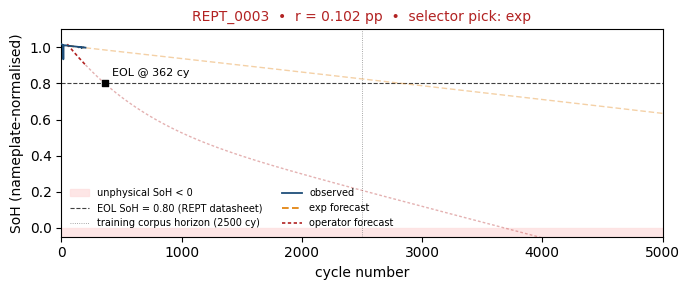

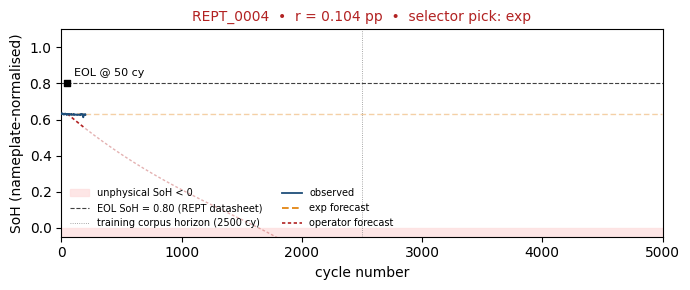

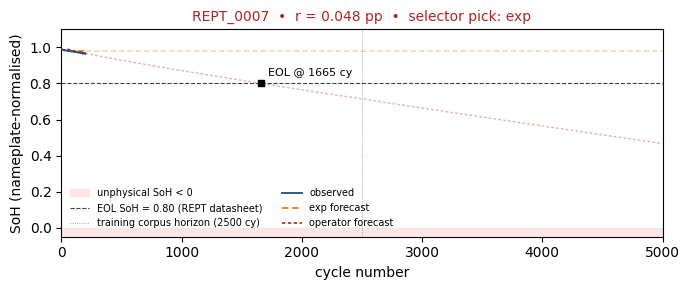

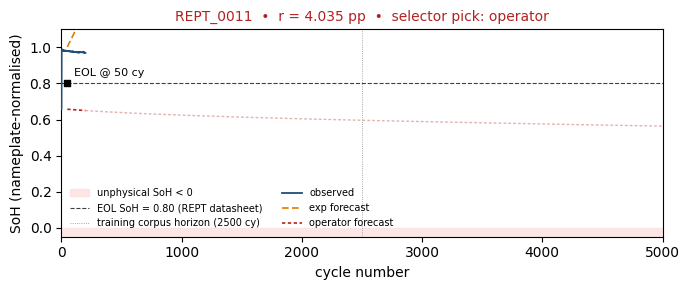

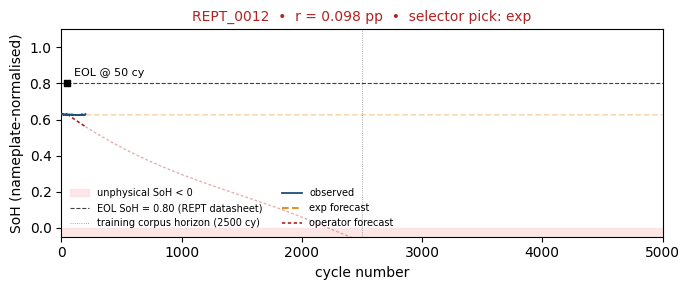

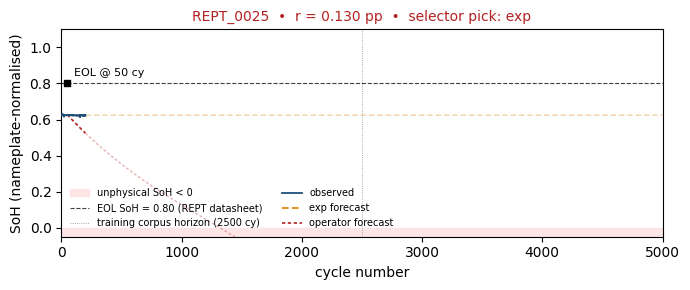

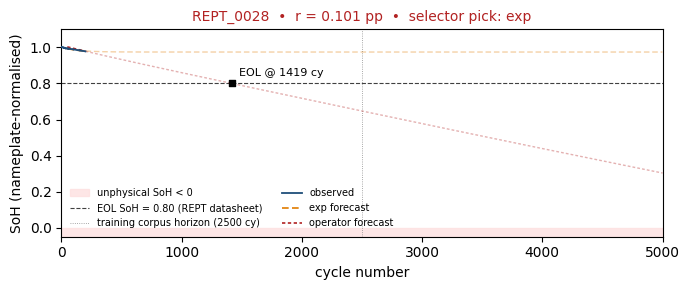

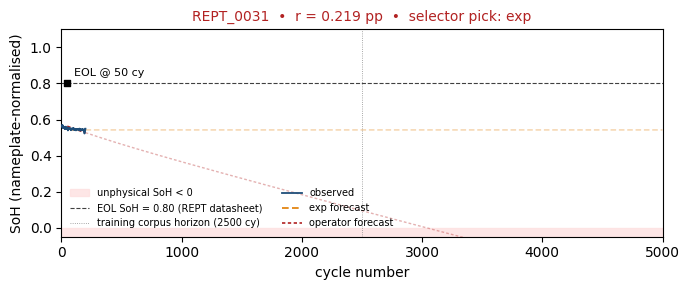

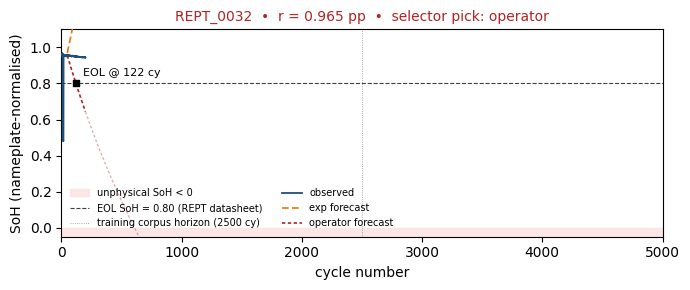

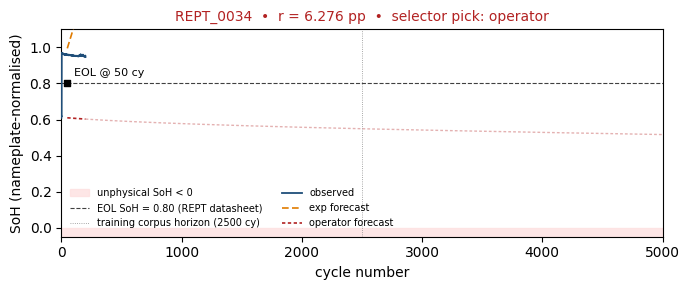

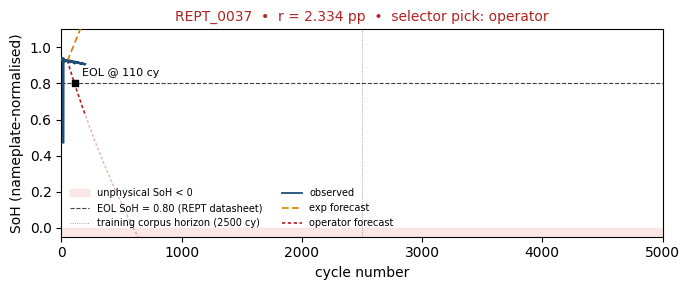

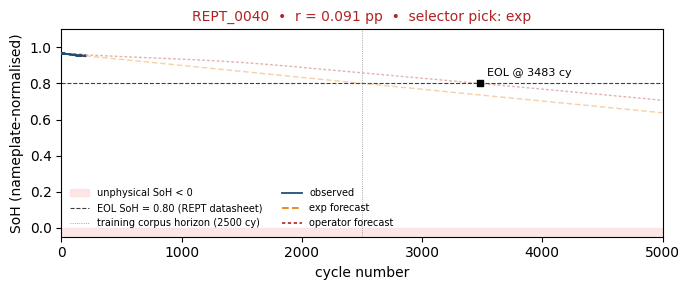

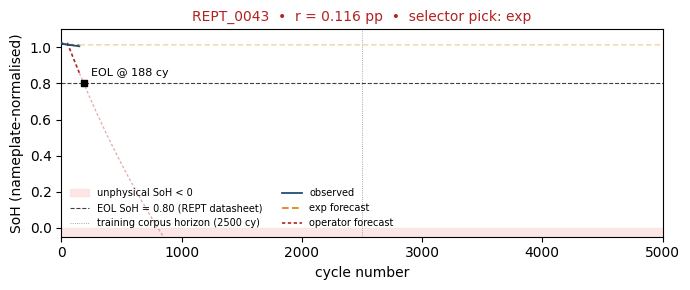

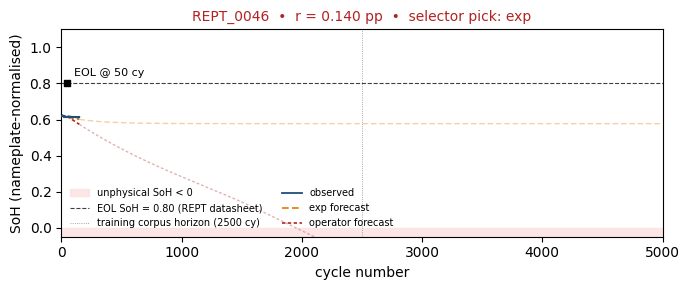

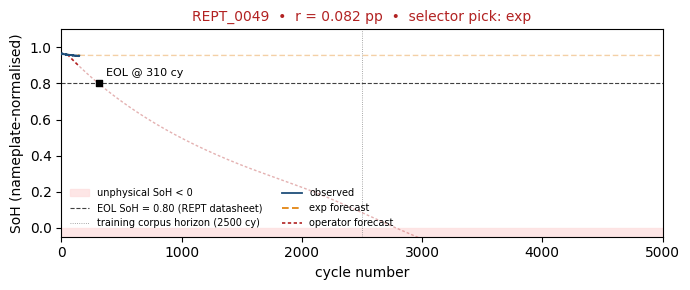

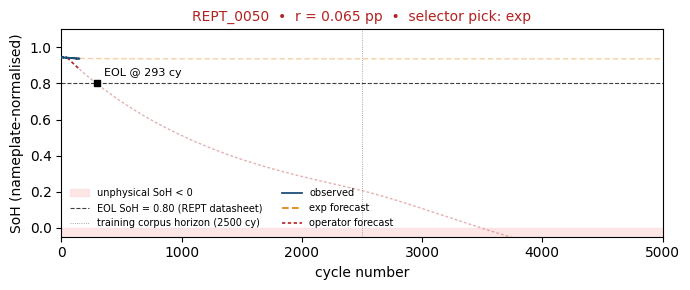

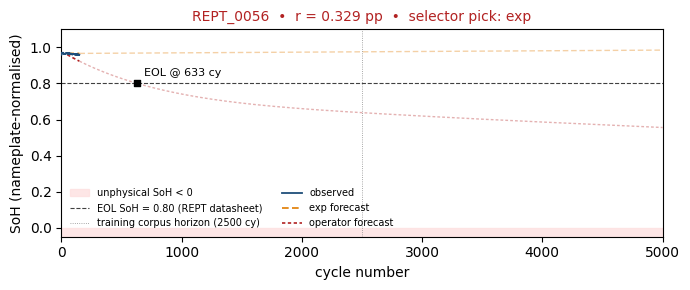

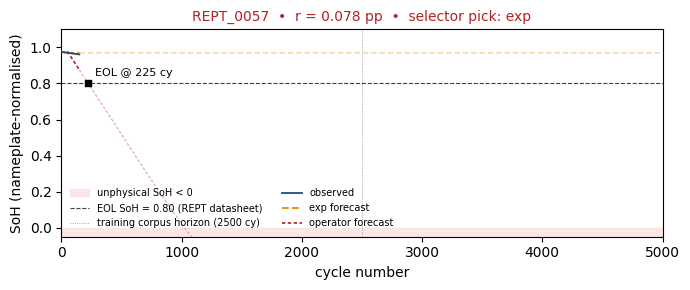

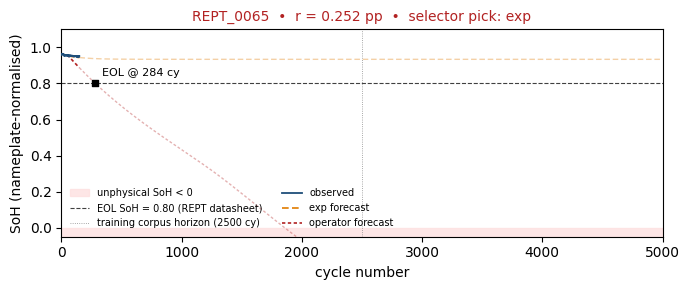

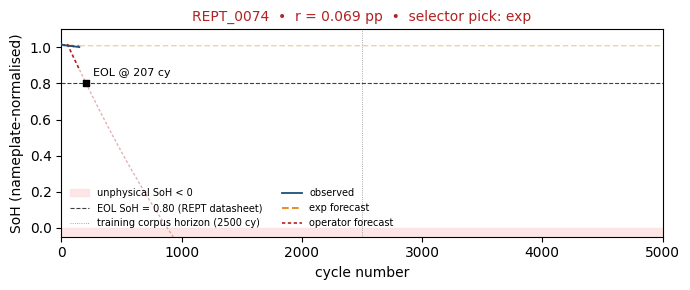

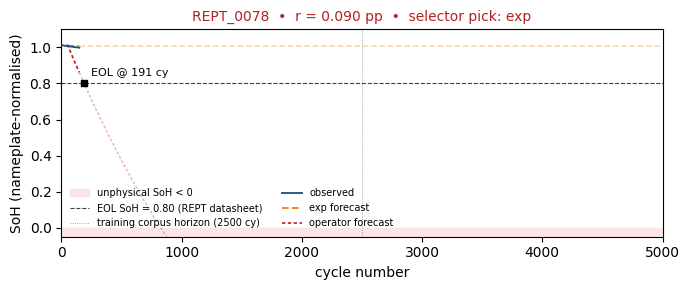

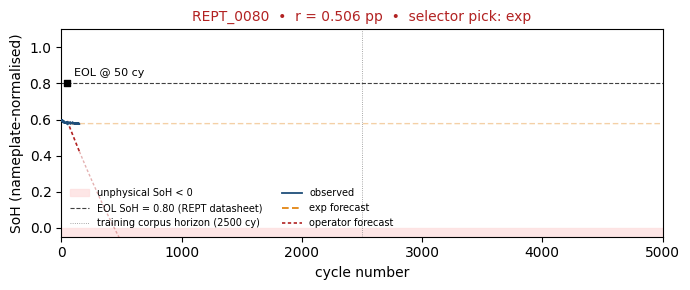

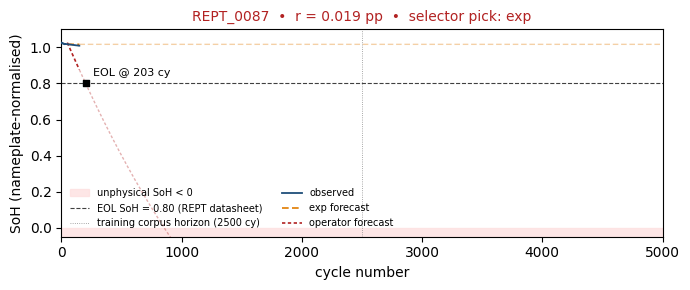

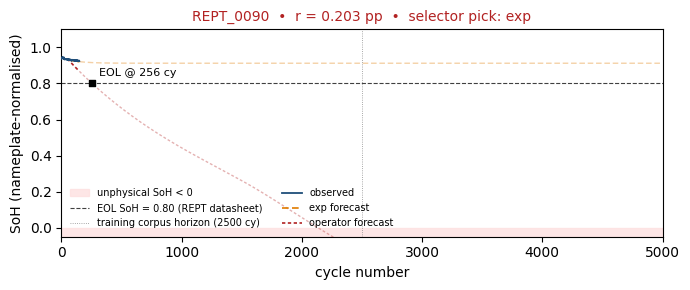


All 59 per-cell figures written to /home/hj/Desktop/PINNs/outputs/results/per_cell_5000cy/


In [10]:
# One INDIVIDUAL figure per cell. All 59 forecasts render inline.
# Each figure shows observed + operator + exp forecasts to 5000 cycles.
# Y-axis clamped to [-0.05, 1.10] so unphysical operator extrapolations
# (SoH < 0) are visible as red-shaded regions but do not distort scale.
avail = long_df[long_df["operator_available"]].copy()
avail = avail.sort_values(["make", "cell"]).reset_index(drop=True)
SUPPLIER_C = {"CALB": "#1F4E79", "EVE": "#2E7D32", "REPT": "#B22222"}
OP_COLOR, EXP_COLOR, OBS_COLOR = "#B22222", "#E07B00", "#1F4E79"
UNPHYS = "#FDE0E0"

per_cell_dir = PROJ / "outputs/results/per_cell_5000cy"
per_cell_dir.mkdir(parents=True, exist_ok=True)

def _plot_one_cell(row):
    mk, cid = row["make"], row["cell_id"]
    pred_n, pred_soh, _ = _long_forecast(cid, mk)
    obs_n_c, obs_soh_c = _load_longterm_soh(cid, mk)
    # Also compute exp forecast to 5000 cy
    ctx = obs_soh_c[:K]
    popt, _ = curve_fit(_exp, np.arange(K, dtype=float), ctx,
                        p0=[ctx[0]-ctx[-1], 1e-3, ctx[-1]], maxfev=10000)
    n_long = np.arange(K, LONG_HORIZON + 1, dtype=float)
    exp_long = _exp(n_long - float(obs_n_c[0]), *popt)
    # Selector pick from Section 2
    sc_row = scored[scored["cell"] == row["cell"]]
    pick = sc_row["pick"].iloc[0] if len(sc_row) else "n/a"
    residual = sc_row["context_holdout_residual_pp"].iloc[0] if len(sc_row) else float("nan")
    eol_cy = row["cycles_to_EOL_0p80"]

    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.axhspan(-0.05, 0.0, color=UNPHYS, alpha=0.8, zorder=0,
               label="unphysical SoH < 0")
    # EOL SoH=0.80 reference only for REPT (datasheet cycle-life spec);
    # CALB/EVE do not have a comparable published threshold.
    if mk == "REPT":
        ax.axhline(0.80, color="0.25", lw=0.8, ls="--", zorder=1,
                   label="EOL SoH = 0.80 (REPT datasheet)")
    ax.axvline(2500, color="0.55", lw=0.6, ls=":", zorder=1,
               label="training corpus horizon (2500 cy)")
    # Observed
    ax.plot(obs_n_c, obs_soh_c, color=OBS_COLOR, lw=1.3,
            label="observed", zorder=4)
    # Exp long-horizon (faded beyond observed)
    obs_max = float(obs_n_c[-1])
    mask_exp = n_long <= obs_max
    ax.plot(n_long[mask_exp], exp_long[mask_exp], color=EXP_COLOR,
            lw=1.2, ls=(0, (4, 2)), zorder=3, label="exp forecast")
    ax.plot(n_long[~mask_exp], exp_long[~mask_exp], color=EXP_COLOR,
            lw=1.0, ls=(0, (4, 2)), alpha=0.35, zorder=3)
    # Operator forecast
    mask_op = pred_n <= obs_max
    ax.plot(pred_n[mask_op], pred_soh[mask_op], color=OP_COLOR,
            lw=1.2, ls=(0, (2, 1.5)), zorder=3, label="operator forecast")
    ax.plot(pred_n[~mask_op], pred_soh[~mask_op], color=OP_COLOR,
            lw=1.0, ls=(0, (2, 1.5)), alpha=0.35, zorder=3)
    # Mark EOL crossing — only for REPT (datasheet threshold)
    if mk == "REPT" and eol_cy is not None and eol_cy <= LONG_HORIZON:
        ax.scatter([eol_cy], [0.80], color="black", s=25, zorder=6,
                   marker="s")
        ax.text(eol_cy, 0.83, f"  EOL @ {int(eol_cy)} cy",
                fontsize=8, va="bottom", ha="left")
    ax.set_xlim(0, LONG_HORIZON)
    ax.set_ylim(-0.05, 1.10)
    ax.set_xlabel("cycle number")
    ax.set_ylabel("SoH (nameplate-normalised)")
    ax.set_title(f"{row['cell']}  •  r = {residual:.3f} pp  •  "
                 f"selector pick: {pick}",
                 fontsize=10, color=SUPPLIER_C[mk])
    ax.legend(fontsize=7, loc="lower left", frameon=False, ncol=2)
    fig.tight_layout()
    out = per_cell_dir / f"{row['cell']}.pdf"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Rendering {len(avail)} individual per-cell figures...\n")
for _, row in avail.iterrows():
    _plot_one_cell(row)

print(f"\nAll {len(avail)} per-cell figures written to {per_cell_dir}/")


## 9. Cycles-to-EOL (SoH = 0.80) summary

Per-cell predicted cycles-to-EOL from the neural operator (extrapolation
warning: values > 500 cy have not been experimentally verified on that
specific cell).

In [11]:
crossed = long_df[long_df["cycles_to_EOL_0p80"].notna()].copy()
never = long_df[long_df["operator_available"] & long_df["cycles_to_EOL_0p80"].isna()]
print(f"crosses EOL within 5000 cy: {len(crossed)}")
print(f"never crosses (very slow fade at anchor θ): {len(never)}")

per_supplier = (crossed.groupby("make")["cycles_to_EOL_0p80"]
                        .agg(["min","median","max","count"])
                        .round(0).astype("Int64"))
print("\ncycles-to-EOL per supplier (only cells that cross):")
print(per_supplier.to_string())


crosses EOL within 5000 cy: 59
never crosses (very slow fade at anchor θ): 0

cycles-to-EOL per supplier (only cells that cross):
      min  median   max  count
make                          
CALB   50      50    50     27
EVE    50     782  2488      6
REPT   50     205  3483     26


/tmp/ipykernel_60433/1952676489.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data, labels=["CALB","EVE","REPT"], patch_artist=True,


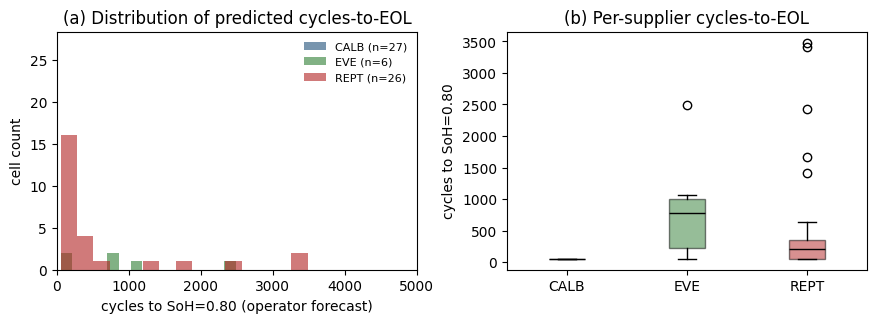

In [12]:
# Histogram + supplier breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4),
    gridspec_kw=dict(wspace=0.25, left=0.08, right=0.98,
                      bottom=0.18, top=0.88))

# (A) Histogram of cycles-to-EOL across all cells
if len(crossed):
    for mk in ["CALB", "EVE", "REPT"]:
        vals = crossed.loc[crossed["make"] == mk,
                            "cycles_to_EOL_0p80"].values
        if len(vals):
            ax1.hist(vals, bins=15, alpha=0.6, label=f"{mk} (n={len(vals)})",
                      color=SUPPLIER_C[mk], edgecolor="none")
    ax1.set_xlabel("cycles to SoH=0.80 (operator forecast)")
    ax1.set_ylabel("cell count")
    ax1.set_title("(a) Distribution of predicted cycles-to-EOL")
    ax1.legend(fontsize=8, frameon=False)
    ax1.set_xlim(0, LONG_HORIZON)

# (B) Boxplot per supplier
if len(crossed):
    data = [crossed.loc[crossed["make"] == mk, "cycles_to_EOL_0p80"].values
            for mk in ["CALB", "EVE", "REPT"]]
    bp = ax2.boxplot(data, labels=["CALB","EVE","REPT"], patch_artist=True,
                      medianprops=dict(color="black"))
    for patch, mk in zip(bp["boxes"], ["CALB","EVE","REPT"]):
        patch.set_facecolor(SUPPLIER_C[mk])
        patch.set_alpha(0.5)
    ax2.set_ylabel("cycles to SoH=0.80")
    ax2.set_title("(b) Per-supplier cycles-to-EOL")

fig.savefig(PROJ / "outputs/results/selector_cycles_to_eol.pdf",
             dpi=200, bbox_inches="tight")
plt.show()


In [13]:
# Persist the long-horizon table
long_df.to_parquet(PROJ / "outputs/results/selector_long_horizon.parquet",
                    index=False)
print("wrote outputs/results/selector_long_horizon.parquet")

# Show the top-fastest and slowest degraders (predicted)
if len(crossed):
    print("\nfastest 10 (shortest predicted cycles-to-EOL):")
    print(crossed.nsmallest(10, "cycles_to_EOL_0p80")[
        ["cell","make","cycles_to_EOL_0p80","soh_at_500","soh_at_2500"]
    ].to_string(index=False))
    print("\nslowest 10 (longest predicted cycles-to-EOL):")
    print(crossed.nlargest(10, "cycles_to_EOL_0p80")[
        ["cell","make","cycles_to_EOL_0p80","soh_at_500","soh_at_2500"]
    ].to_string(index=False))


wrote outputs/results/selector_long_horizon.parquet

fastest 10 (shortest predicted cycles-to-EOL):
     cell make  cycles_to_EOL_0p80  soh_at_500  soh_at_2500
CALB_0001 CALB                  50    0.021205    -1.537804
CALB_0002 CALB                  50   -0.072667    -1.605179
CALB_0003 CALB                  50    0.148505    -1.145480
CALB_0004 CALB                  50   -0.050521    -1.527256
CALB_0005 CALB                  50    0.660652     0.513924
CALB_0006 CALB                  50    0.418343    -0.508223
CALB_0007 CALB                  50    0.533927     0.304574
CALB_0008 CALB                  50    0.522192     0.270013
CALB_0009 CALB                  50    0.094205    -1.621240
CALB_0010 CALB                  50    0.378817    -1.152174

slowest 10 (longest predicted cycles-to-EOL):
     cell make  cycles_to_EOL_0p80  soh_at_500  soh_at_2500
REPT_0040 REPT                3483    0.948936     0.858827
REPT_0001 REPT                3415    0.989374     0.863892
 EVE_0002  EV

## 10. Verdict marker

**Section 1-6 verdict** (frozen selector applied to all Longterm cells):

- [ ] **PASS** — selector distributes cells across both models in a
  supplier-plausible way (matches the 3-external-cell finding: EVE
  routes to operator more often than CALB/REPT).
- [ ] **PASS WITH LIMITATIONS** — distribution is dominated by one
  model; may reflect that τ was tuned on synthetic corpus rather than
  real cells.
- [ ] **FAIL** — nearly all cells route the same way; selector is
  essentially degenerate on this cohort.

**Section 7-8 verdict** (long-horizon operator projections):

- [ ] **PASS** — operator forecast to 5000 cycles is monotonic and
  physically plausible on the cells where it runs; cycles-to-EOL
  distribution is supplier-plausible.
- [ ] **PASS WITH LIMITATIONS** — labelled as EXTRAPOLATION beyond
  the abstract's validated 500-cycle horizon; long-horizon values
  are not experimentally verified on external cells.
- [ ] **FAIL** — projections not monotone / unphysical / diverge.
